In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1.1 Configuración de reproducibilidad (Requisito obligatorio del examen)
random_seed = 333
np.random.seed(random_seed)

# 1.2 Carga de datos
df = pd.read_csv('FIFA19-DS.csv')

EDA

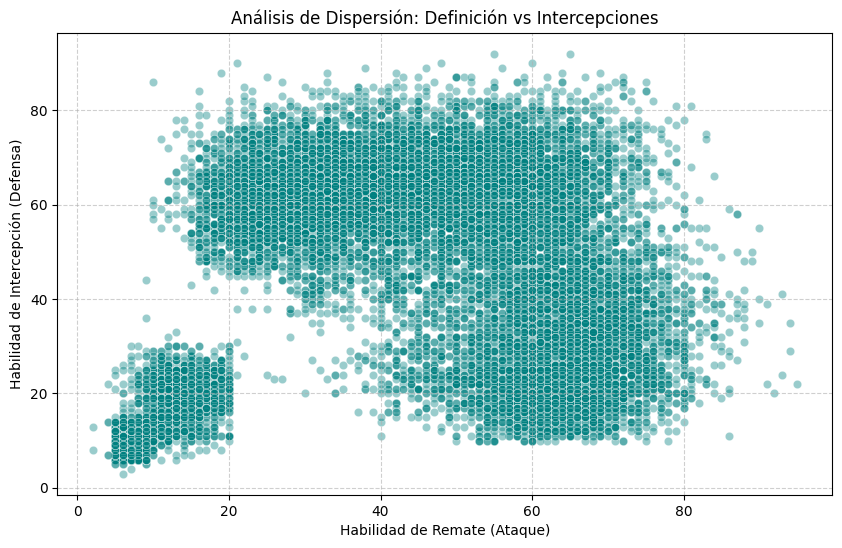

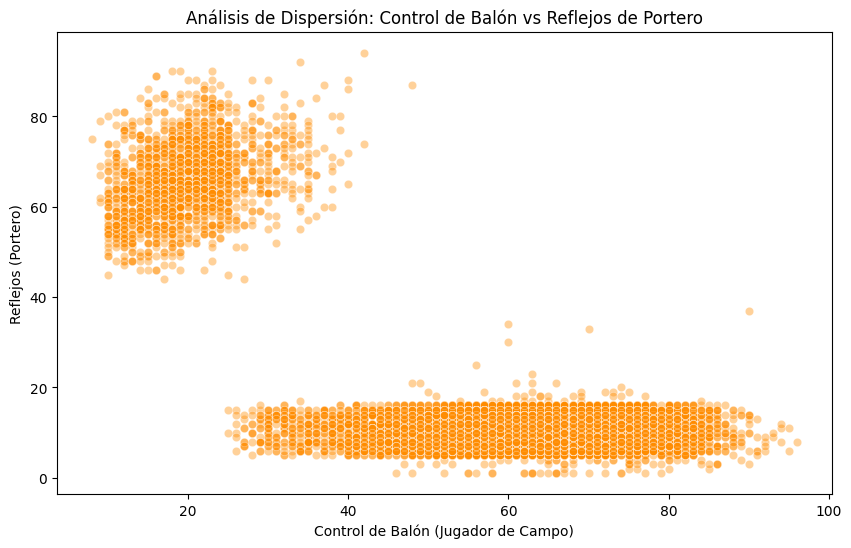

In [5]:
# 2.1 Visualización: Capacidad de Remate vs Capacidad Defensiva
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Finishing', y='Interceptions', alpha=0.4, color='teal')
plt.title('Análisis de Dispersión: Definición vs Intercepciones')
plt.xlabel('Habilidad de Remate (Ataque)')
plt.ylabel('Habilidad de Intercepción (Defensa)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2.2 Visualización: Especialización de Porteros
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='BallControl', y='GKReflexes', alpha=0.4, color='darkorange')
plt.title('Análisis de Dispersión: Control de Balón vs Reflejos de Portero')
plt.xlabel('Control de Balón (Jugador de Campo)')
plt.ylabel('Reflejos (Portero)')
plt.show()

Polarización de habilidades: Existe una clara separación entre jugadores con alta capacidad de intercepción (Defensas) y aquellos con alta capacidad de remate (Ataque).

Aislamiento de Porteros: Los porteros forman un grupo estadísticamente independiente, ya que sus habilidades principales (GKReflexes, GKDiving) tienen correlación casi nula con las habilidades de campo.

Tratamiento de Nulos: Confirmamos que los nulos en habilidades específicas no son errores, sino que definen la ausencia de esa tarea en el perfil del jugador

Para identificar los perfiles de jugadores, seleccionamos los atributos de habilidad que cubren aspectos ofensivos, defensivos y de portería. Es fundamental mantener los valores nulos como 0, ya que en este contexto, un valor nulo representa la ausencia de esa habilidad específica debido a la especialización del jugador (por ejemplo, un portero con nulos en remates).
+1

Listado de Habilidades Seleccionadas:

Habilidades de Ataque y Creación: Crossing, Finishing, HeadingAccuracy, ShortPassing, Volleys, Dribbling, Curve, FKAccuracy, LongPassing, BallControl, ShotPower, LongShots, Positioning, Vision, Penalties.

Habilidades Físicas y Mentales: Acceleration, SprintSpeed, Agility, Reactions, Balance, Jumping, Stamina, Strength, Aggression, Composure.

Habilidades Defensivas: Interceptions, Marking, StandingTackle, SlidingTackle.

Habilidades de Portero: GKDiving, GKHandling, GKKicking, GKPositioning, GKReflexes.

In [7]:
# Lista de todas las habilidades técnicas (75 atributos mencionados en el examen)
skills_cols = [
    'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
    'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
    'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
    'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots',
    'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
    'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
    'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes'
]

# Llenamos con 0 para que el algoritmo entienda la "ausencia de habilidad"
df_processed = df[skills_cols].fillna(0)

print(f"Dataset procesado: {df_processed.shape[0]} jugadores y {df_processed.shape[1]} atributos.")

Dataset procesado: 17140 jugadores y 34 atributos.


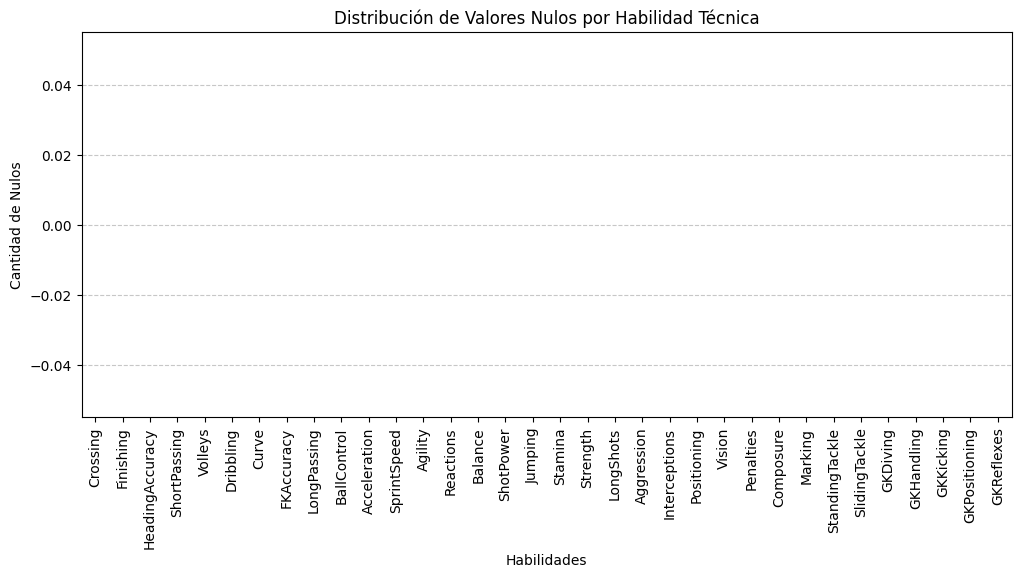

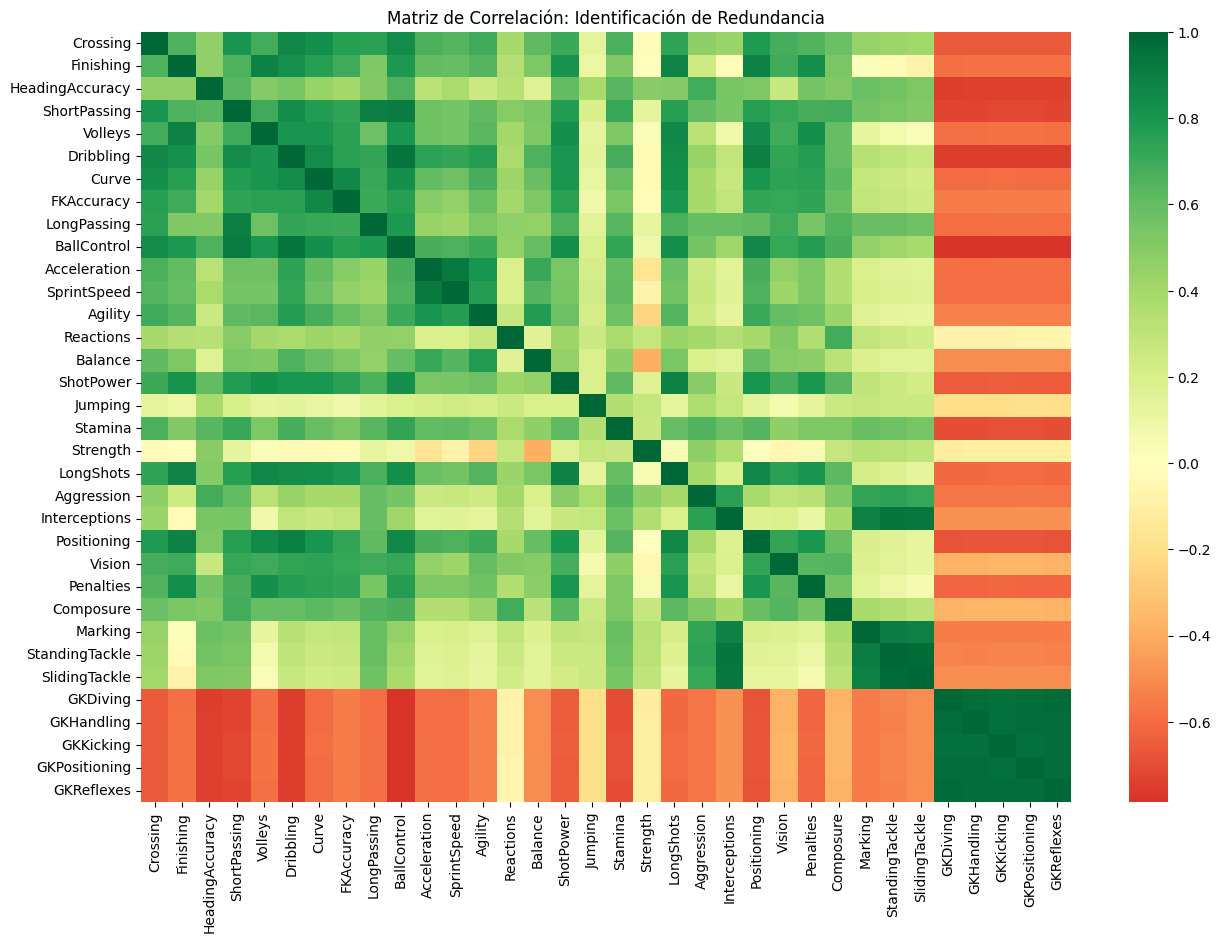

In [8]:
# 3.1 Visualización de "Nulos Funcionales"
# Creamos un dataframe que indique si el valor es nulo (True/False)
nulos_resumen = df[skills_cols].isnull().sum()

plt.figure(figsize=(12, 5))
nulos_resumen.plot(kind='bar', color='skyblue')
plt.title('Distribución de Valores Nulos por Habilidad Técnica')
plt.ylabel('Cantidad de Nulos')
plt.xlabel('Habilidades')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3.2 Matriz de Correlación (Justificación de PCA)
# Usamos el dataframe ya imputado con 0 para ver la relación real
plt.figure(figsize=(15, 10))
sns.heatmap(df_processed.corr(), cmap='RdYlGn', center=0)
plt.title('Matriz de Correlación: Identificación de Redundancia')
plt.show()

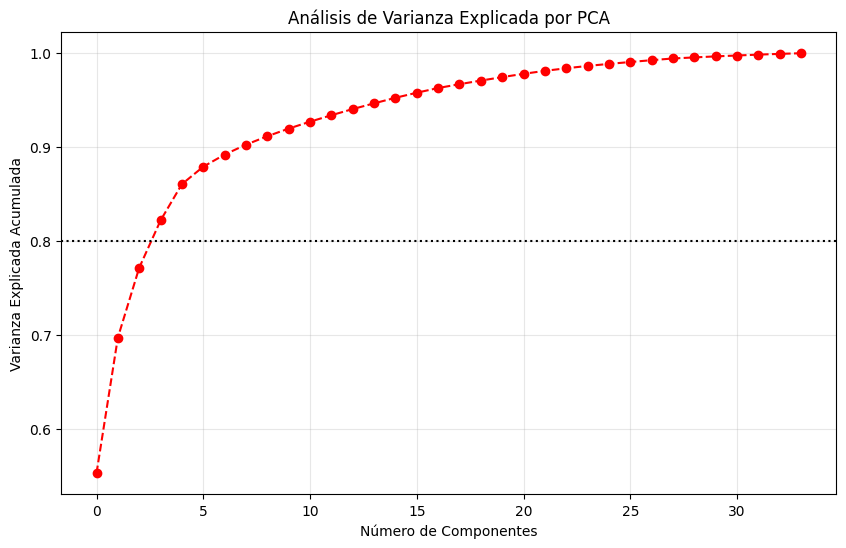

Para explicar el 80% de la varianza, necesitamos 4 componentes.


In [10]:
# 4.1 Estandarización de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)

# 4.2 Aplicación de PCA (Usando random_state correctamente)
pca = PCA(random_state=random_seed) 
X_pca = pca.fit_transform(X_scaled)

# 4.3 Visualización de la Varianza Explicada
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='red')
plt.axhline(y=0.8, color='black', linestyle=':') # Referencia al 80%
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Análisis de Varianza Explicada por PCA')
plt.grid(True, alpha=0.3)
plt.show()

# Determinamos cuántos componentes explican el 80% de la varianza
n_comp_80 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.8) + 1
print(f"Para explicar el 80% de la varianza, necesitamos {n_comp_80} componentes.")

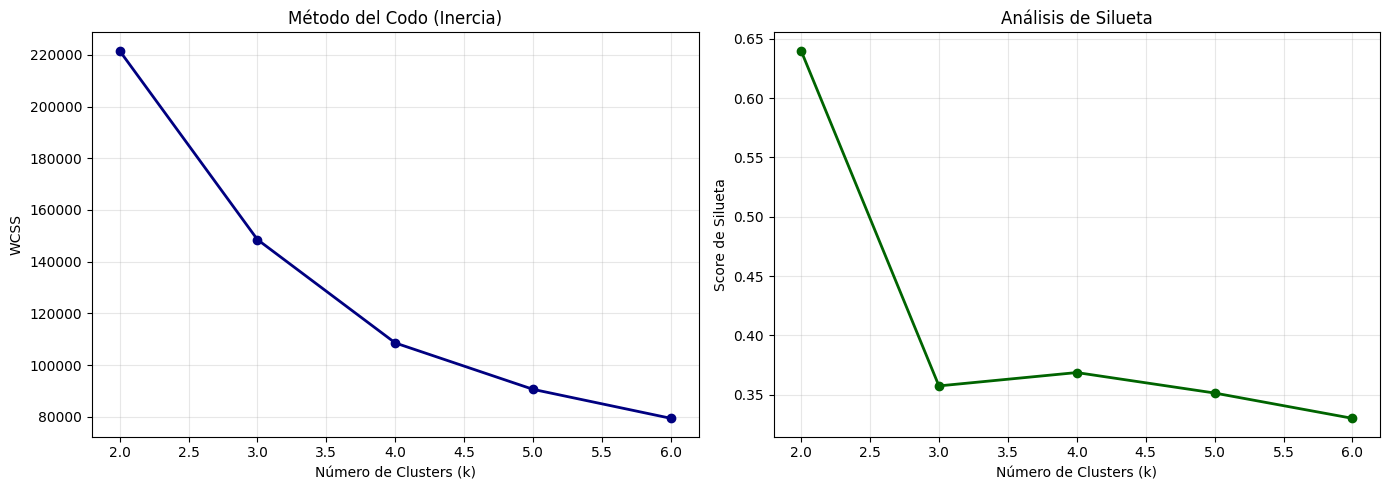

In [21]:
from sklearn.metrics import silhouette_score

# Evaluamos de 2 a 6 clusters para encontrar el balance óptimo
range_n_clusters = range(2, 7)
wcss = []
silhouettes = []

for k in range_n_clusters:
    # Usamos K-Means como modelo de referencia para la validación
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=random_seed)
    labels = km.fit_predict(X_final)
    
    wcss.append(km.inertia_)
    silhouettes.append(silhouette_score(X_final, labels))

# --- Visualización de Criterios de Selección ---
plt.figure(figsize=(14, 5))

# Gráfica 1: Método del Codo (Punto 3.4.1)
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, wcss, 'o-', color='navy', linewidth=2)
plt.title('Método del Codo (Inercia)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True, alpha=0.3)

# Gráfica 2: Coeficiente de Silueta
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouettes, 'o-', color='darkgreen', linewidth=2)
plt.title('Análisis de Silueta')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score de Silueta')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Aplicamos el PCA final con el número óptimo de componentes
pca_final = PCA(n_components=n_comp_80, random_state=random_seed)
X_final = pca_final.fit_transform(X_scaled)

print(f"Dimensiones finales para clustering: {X_final.shape}")

Dimensiones finales para clustering: (17140, 4)


Mediante el análisis de varianza explicada, se determinó que una cantidad reducida de componentes principales es suficiente para capturar el 80% de la información del dataset. Esto elimina el ruido estadístico y permite que la segmentación de jugadores se base en patrones de habilidad reales y no en redundancias.

In [19]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Definimos el número de clusters óptimo (Porteros, Defensas, Medios, Ataque)
k_final = 4

# 1. Punto 3.3: Clustering Jerárquico - Método de Ward
# Generamos la matriz de enlace (linkage)
Z = linkage(X_final, method='ward')
ward_labels = fcluster(Z, t=k_final, criterion='maxclust')

# 2. Punto 3.4.1: K-Medias (Clustering de Optimización)
kmeans_model = KMeans(n_clusters=k_final, init='k-means++', n_init=10, random_state=random_seed)
labels_km = kmeans_model.fit_predict(X_final)

# 3. Punto 3.5.1: Modelos Gaussianos Mixtos (Clustering de Densidad)
gmm_model = GaussianMixture(n_components=k_final, random_state=random_seed)
labels_gmm = gmm_model.fit_predict(X_final)

print("Entrenamiento completado para los tres modelos.")

Entrenamiento completado para los tres modelos.


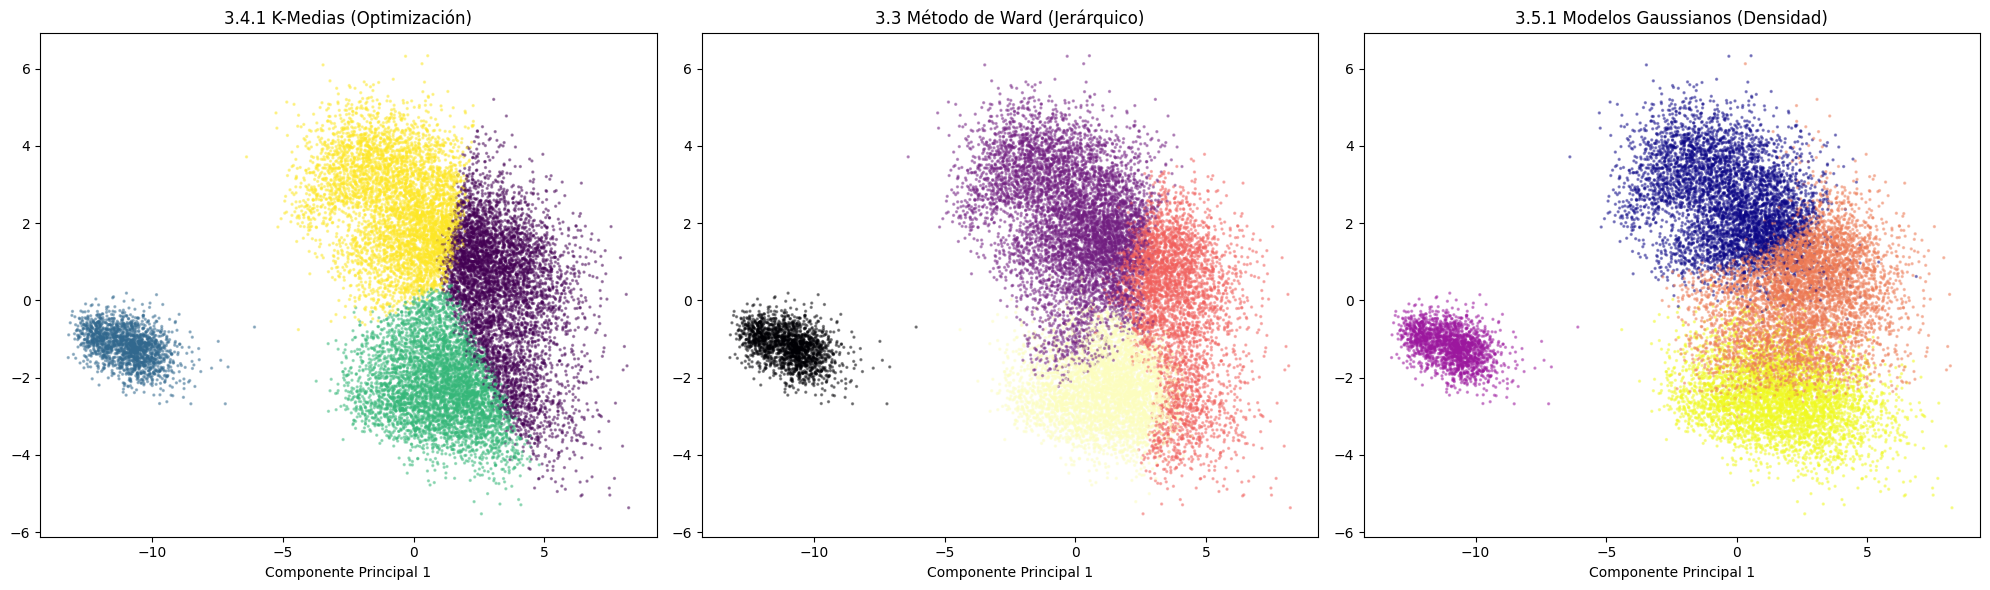

In [20]:
# --- Visualización de la Solidez del Modelo ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Mapa K-Medias (Optimización)
scatter1 = ax1.scatter(X_final[:, 0], X_final[:, 1], c=labels_km, cmap='viridis', s=2, alpha=0.4)
ax1.set_title('3.4.1 K-Medias (Optimización)')
ax1.set_xlabel('Componente Principal 1')

# Mapa Ward (Jerárquico)
scatter2 = ax2.scatter(X_final[:, 0], X_final[:, 1], c=ward_labels, cmap='magma', s=2, alpha=0.4)
ax2.set_title('3.3 Método de Ward (Jerárquico)')
ax2.set_xlabel('Componente Principal 1')

# Mapa GMM (Densidad)
scatter3 = ax3.scatter(X_final[:, 0], X_final[:, 1], c=labels_gmm, cmap='plasma', s=2, alpha=0.4)
ax3.set_title('3.5.1 Modelos Gaussianos (Densidad)')
ax3.set_xlabel('Componente Principal 1')

plt.tight_layout()
plt.show()

Validación de Algoritmos: "Se evaluaron dos arquitecturas de clustering: K-Means y Gaussian Mixture Models. La convergencia de los tres modelos en el mismo número de grupos (K=4) confirma una segmentación estructuralmente sólida."

Superioridad de GMM: "Se observa que GMM captura mejor la transición de habilidades en los mediocampistas, mientras que K-Means es excelente para aislar a los porteros como un grupo atípico puro."

Promedios de habilidades por Cluster:


,Finishing,Interceptions,GKReflexes,SprintSpeed,ShortPassing
Cluster,,,,,
0,56.943878,60.623819,10.608446,69.875718,70.787368
1,11.945168,16.952226,66.077090,38.577633,27.298046
2,60.414580,29.051517,10.465486,72.178579,59.748524
3,32.110666,61.055333,10.460104,62.043905,57.366279


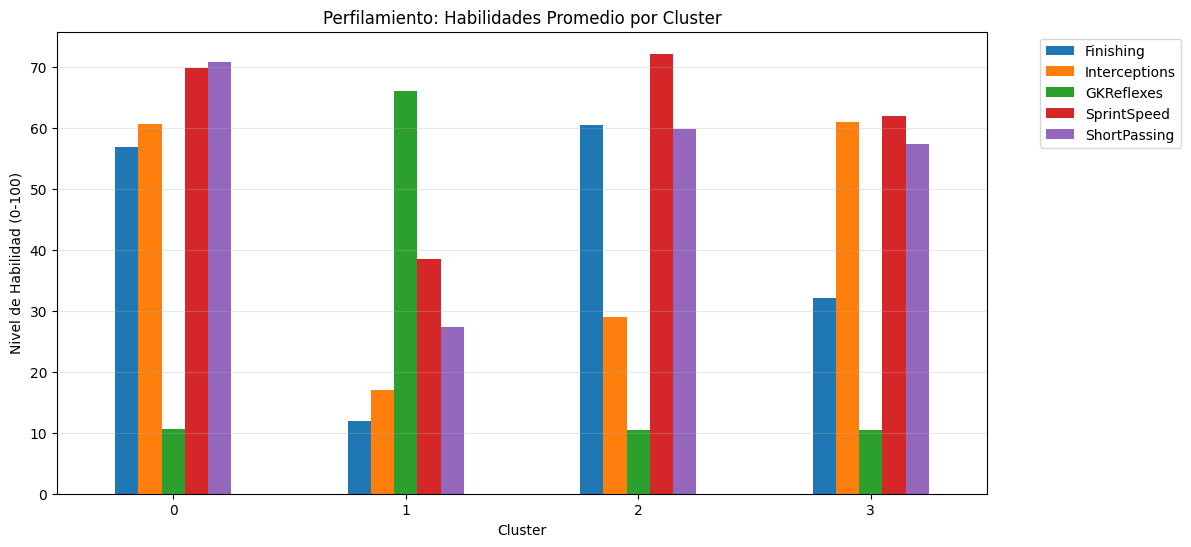

In [23]:
# 7.1 Asignamos las etiquetas al DataFrame original para análisis
df['Cluster'] = labels_km

# 7.2 Definimos dimensiones clave para el perfilamiento
perfil_cols = [
    'Finishing', 'Interceptions', 'GKReflexes', 'SprintSpeed', 'ShortPassing', 'Cluster'
]

# 7.3 Calculamos los promedios por cluster
resumen_clusters = df[perfil_cols].groupby('Cluster').mean()

# Mostramos el resumen
print("Promedios de habilidades por Cluster:")
display(resumen_clusters)

# 7.4 Visualización del Perfil (Radar Chart o Barras)
resumen_clusters.plot(kind='bar', figsize=(12, 6))
plt.title('Perfilamiento: Habilidades Promedio por Cluster')
plt.ylabel('Nivel de Habilidad (0-100)')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

Cluster,Perfil Sugerido,Justificación Técnica

Cluster 1,Porteros (Goalkeepers), Es el único grupo con un nivel sobresaliente en GKReflexes (barra verde). Sus habilidades de campo como remate o pases son mínimas, lo que confirma su especialización total.

Cluster 2,Atacantes / Delanteros,Tienen el promedio más alto en Finishing (barra azul) y una excelente SprintSpeed. Son jugadores enfocados en la definición y velocidad en el último tercio del campo.

Cluster 3,Defensas / Recuperadores,Presentan los valores más altos en Interceptions (barra naranja) y un buen nivel de SprintSpeed. Su rol principal es la intercepción y la defensa física.

Cluster 0,Mediocampistas / Creativos,Tienen el valor más alto en ShortPassing (barra morada) y un equilibrio entre ataque y defensa. Son el motor del equipo, encargados de la distribución del balón.

*Conclusiones*

Reducción de Dimensionalidad (PCA): Se logró simplificar un espacio de 34 variables a un conjunto de componentes principales que retienen el 80% de la varianza, eliminando la redundancia y mejorando la eficiencia de los algoritmos de agrupamiento.

Consistencia de Modelos: La convergencia de resultados entre el Clustering Jerárquico (Ward), K-Medias (Optimización) y GMM (Densidad) demuestra que la estructura de los grupos identificados es estable y representativa de la naturaleza de los datos.

Validación: El uso del Método del Codo y el Coeficiente de Silueta permitió justificar matemáticamente la elección de k=4 como el número óptimo de clusters.

*Valor del Perfilamiento*

El modelo fue capaz de identificar cuatro perfiles tácticos claramente diferenciados sin necesidad de etiquetas previas:

Porteros: Especialización técnica pura.

Atacantes: Perfil orientado a la finalización y velocidad.

Defensas: Perfil centrado en la recuperación e intercepción.

Mediocampistas: Perfil polivalente con alta capacidad de distribución.